In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm

In [3]:
#function
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
        
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    if max_err > check_tol:
        mag = np.abs(eigvals)
        print("Sorted |eigvals|:", np.sort(mag))
        raise RuntimeError(
            fr"Self-consistency violated: max |Δ| = {max_err}"
        )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

#current1
def Gr_DD(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E,ets=1e-6j):
    d = H_q1.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E+ets)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E+ets)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i < N//2:
            H_qi = H_q1
        elif i >=N//2:
            H_qi = H_q2

        # 左端点
        if i == 0:
            A_DD[i][i] = EI_gai - H_qi - Sigma_L

        # 右端点
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_qi - Sigma_R

        # 中间
        else:
            A_DD[i][i] = EI_gai - H_qi

        # hopping
        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD = np.block(A_DD)
    G_DD = np.linalg.inv(A_DD)
    return G_DD , A_DD , Sigma_R , Sigma_L 

def J(V ,mu_L ,mu_R ,E, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-6j):
    d = T_12.shape[0]
    EI_gai_L = np.block([
        [(E+ets-V/2*1)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E+ets-V/2*1)*s0]
    ])

    A_l = EI_gai_L - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L_q = zinengr_L(T_LD, gcl)

    EI_gai_R = np.block([
        [(E+ets+V/2*1)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E+ets+V/2*1)*s0]
    ])

    A_r = EI_gai_R - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R_q = zinengr_L(T_RD, gcr)

    zhanhuan_L = np.zeros((N*d, N*d), dtype=complex)
    zhanhuan_R = np.zeros((N*d, N*d), dtype=complex)
    zhanhuan_L[0*d:(1)*d, (0)*d:(1)*d]=1j*(Sigma_L_q-Sigma_L_q.conj().T)
    zhanhuan_R[(N-1)*d:(N)*d, (N-1)*d:(N)*d]=1j*(Sigma_R_q-Sigma_R_q.conj().T)

    G_DD,_,_,_=Gr_DD(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E,ets=ets)
    T_E_shang=np.trace(zhanhuan_L @ G_DD @ zhanhuan_R @ G_DD.conj().T)

    f_L_E=1/(1+np.exp((E-mu_L-V/2)/KBT))
    f_R_E=1/(1+np.exp((E-mu_R+V/2)/KBT))

    return T_E_shang*(f_L_E-f_R_E)
    #return np.trace(Jmat)*(-1j)*KBT

def J_new(V ,mu_L ,mu_R ,E, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-6j):
    d=T_12.shape[0]
    H_l=H_onsite(t_L,mu_L-V/2, 0,0, 1,0)
    H_q1=H_onsite(t_L,mu_L-V/2, 0,0, 1,0)
    H_q2=H_onsite(t_R,mu_R+V/2, Vz,varphi_s, 2,chaodaojiao)
    H_r=H_onsite(t_R,mu_R+V/2, Vz,varphi_s, 2,chaodaojiao)
    G_DD,_,Sigma_R_q,Sigma_L_q= Gr_DD(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E,ets=ets)
    zhanhuan_L = np.zeros((N*d, N*d), dtype=complex)
    zhanhuan_R = np.zeros((N*d, N*d), dtype=complex)
    zhanhuan_L[0*d:(1)*d, (0)*d:(1)*d]=1j*(Sigma_L_q-Sigma_L_q.conj().T)
    zhanhuan_R[(N-1)*d:(N)*d, (N-1)*d:(N)*d]=1j*(Sigma_R_q-Sigma_R_q.conj().T)

    
    T_E_shang=np.trace(zhanhuan_L @ G_DD @ zhanhuan_R @ G_DD.conj().T)

    f_L_E=1/(1+np.exp((E-mu_L-V/2)/KBT))
    f_R_E=1/(1+np.exp((E-mu_R+V/2)/KBT))

    return T_E_shang*(f_L_E-f_R_E)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu, V ,mu_L ,mu_R , N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-6j):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        JJJJ=J_new(V ,mu_L ,mu_R ,1j*wn, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, ets=ets)
        J_sum += np.real(JJJJ)
    return (J_sum)

In [5]:
#右边
t_R=25
mu_R=0

Vz=2
varphi_s = np.pi*0  #z_x平面

delta=1
chaodaojiao=0

alpha_R=2
a=1

#左边
t_L=30
mu_L=0

#耦合
t_c=15

T_Tc=0.5
Delta = delta * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
KBT=2 * delta * T_Tc / 3.5
shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*1

N=2

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(t,u, m_zx,Bjiao, weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X= np.zeros((2,2))
        HX_block=-(u-2*t)*s0 
    elif weizhi==2:
        Delta_X= Delta * np.exp(1j*chaodaojiao) * 1j * sy
        HX_block=-(u-2*t)*s0 + m_zx*np.cos(Bjiao)*sz+ m_zx*np.sin(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(t,alpha_R):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*alpha_R*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(t_L,mu_L, 0,0, 1,0)
H_L_right_to_left_hop=H_hop(t_L,0)

#中间矩阵信息
H_center_to_L=H_hop(t_L,0)

H_center_qian =H_onsite(t_L,mu_L, 0,0, 1,0)
H_center_hou  =H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)
H_center_right_to_left_hop=H_hop(t_c,0)

H_R_to_center=H_hop(t_R,alpha_R)

#右边矩阵信息
H_R_onsite=H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)
H_R_right_to_left_hop=H_hop(t_R, alpha_R)

#输入矩阵
H_q1=H_center_qian
H_q2=H_center_hou
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center



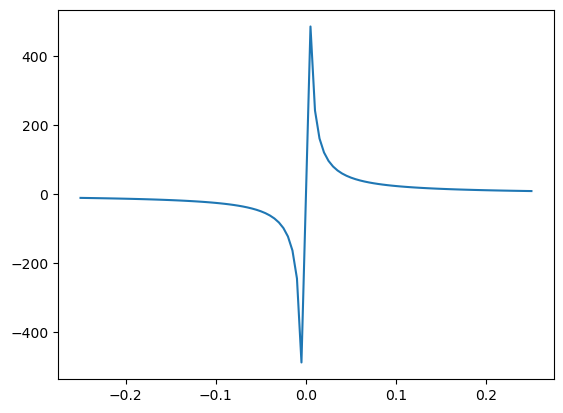

In [6]:
V_set=np.linspace(-0.25,0.25,101)
J_suan_set=[]
for V in V_set:
     J_suan=J_matsubara_sum(shumu, V ,mu_L ,mu_R , N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-6j)
     J_suan_set.append(J_suan)
plt.plot(V_set,J_suan_set)
#plt.ylim(-0.01,0.01)

(-0.001, 0.01)

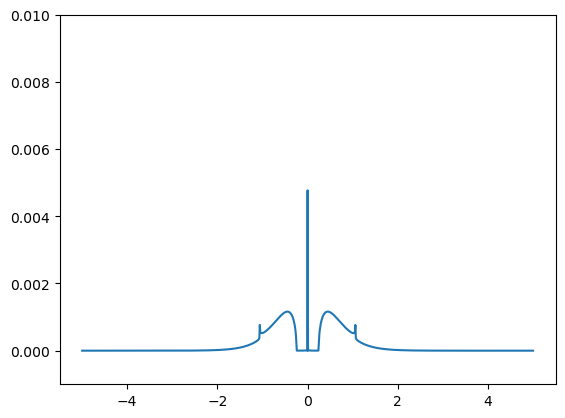

In [10]:
E_set=np.linspace(-5,5,1001)
J_suan_set=[]
V=0.03
for E in E_set:
     J_suan=J_new(V ,mu_L ,mu_R ,E, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-4j)
     J_suan_set.append(J_suan)
plt.plot(E_set,J_suan_set)
plt.ylim(-0.001,0.01)

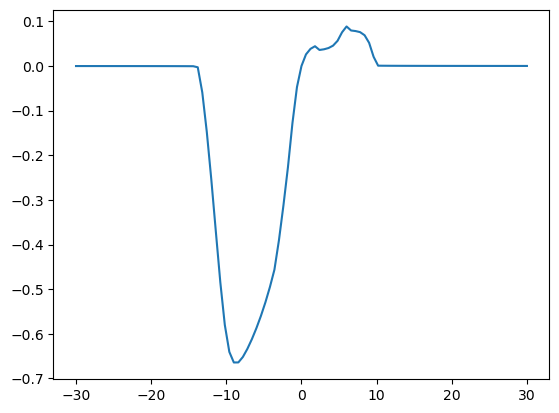

In [20]:
from scipy.integrate import quad

def integrand(E):
    return np.real(J_new(V ,mu_L ,mu_R ,E, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-3j))

V_set=np.linspace(-30,30,101)
J_suan_set=[]
for V in V_set:
    I, err = quad(integrand, -5, 5, limit=500)
    J_suan_set.append(I)
    #print(V,I,err)
plt.plot(V_set,J_suan_set)


In [12]:
from scipy.integrate import quad

def integrand(E):
    return np.real(J(V ,mu_L ,mu_R ,E, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-3j))

V_set=np.linspace(-0.4,0.4,101)
J_suan_set=[]
for V in V_set:
    I, err = quad(integrand, -5, 5, limit=500)
    J_suan_set.append(I)
    #print(V,I,err)
plt.plot(V_set,J_suan_set)


KeyboardInterrupt: 

In [33]:
#current1
def Gr_DD_wn(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn,ets=1e-6j):
    d = H_q1.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(wn*1j+ets)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (wn*1j+ets)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i < N//2:
            H_qi = H_q1
        else:
            H_qi = H_q2

        # 左端点
        if i == 0:
            A_DD[i][i] = EI_gai - H_qi - Sigma_L

        # 右端点
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_qi - Sigma_R

        # 中间
        else:
            A_DD[i][i] = EI_gai - H_qi

        # hopping
        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD = np.block(A_DD)
    G_DD = np.linalg.inv(A_DD)
    return G_DD , A_DD , Sigma_R , Sigma_L 

def J_wn(V ,mu_L ,mu_R ,wn, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=1e-6j):
    d = T_12.shape[0]
    EI_gai_L = np.block([
        [(wn*1j+ets-V/2)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (wn*1j+ets-V/2)*s0]
    ])

    A_l = EI_gai_L - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L_q = zinengr_L(T_LD, gcl)

    EI_gai_R = np.block([
        [(wn*1j+ets+V/2)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (wn*1j+ets+V/2)*s0]
    ])

    A_r = EI_gai_R - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R_q = zinengr_L(T_RD, gcr)

    zhanhuan_L = np.zeros((N*d, N*d), dtype=complex)
    zhanhuan_R = np.zeros((N*d, N*d), dtype=complex)
    zhanhuan_L[0*d:(1)*d, (0)*d:(1)*d]=1j*(Sigma_L_q-Sigma_L_q.conj().T)
    zhanhuan_R[(N-1)*d:(N)*d, (N-1)*d:(N)*d]=1j*(Sigma_R_q-Sigma_R_q.conj().T)

    G_DD,_,_,_=Gr_DD_wn(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn,ets=ets)
    T_E_shang=np.trace(zhanhuan_L @ G_DD @ zhanhuan_R @ G_DD.conj().T)

    f_L_E=1/(1+np.exp((wn*1j-mu_L-V/2)/KBT))
    f_R_E=1/(1+np.exp((wn*1j-mu_R+V/2)/KBT))

    return T_E_shang*(f_L_E-f_R_E)
    #return np.trace(Jmat)*(-1j)*KBT

def J_sum_wn(shumu,H_q1,H_q2, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N,ets=1e-6j):
    wn_list=matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        J_ll =J_wn(V ,mu_L ,mu_R ,wn, N, H_q1, H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r,ets=ets)

        J_sum += np.real(J_ll)
    return (J_sum)

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()


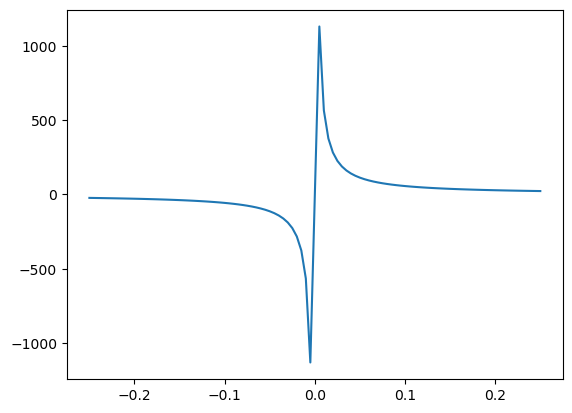

In [94]:
V_set=np.linspace(-0.25,0.25,101)
J_suan_set=[]
for V in V_set:
     J_suan=J_sum_wn(shumu,H_q1,H_q2, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N,ets=1e-6j)
     J_suan_set.append(J_suan)
plt.plot(V_set,J_suan_set)

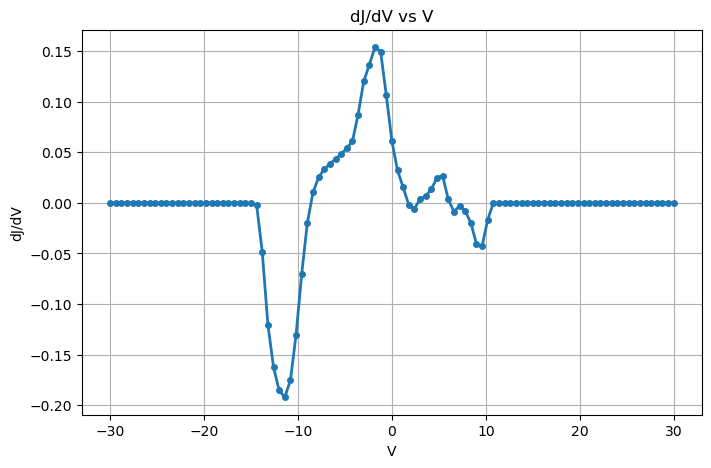

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def compute_dJdV(V_set, J_suan_set):
    V = np.asarray(V_set, dtype=float)
    J = np.asarray(J_suan_set, dtype=float)
    
    if len(V) < 2:
        raise ValueError("数据点至少需要2个")
    
    dJdV = np.zeros_like(J, dtype=float)
    
    # ===== 边界点 =====
    # 第一个点：用本身和下一个点（前向差分）
    dJdV[0] = (J[1] - J[0]) / (V[1] - V[0])
    
    # 最后一个点：用本身和前一个点（后向差分）
    dJdV[-1] = (J[-1] - J[-2]) / (V[-1] - V[-2])
    
    # ===== 中间点 =====
    # 用左右两个邻近点（中心差分）
    for i in range(1, len(J)-1):
        dJdV[i] = (J[i+1] - J[i-1]) / (V[i+1] - V[i-1])
    
    return V, dJdV



V_set =     V_set     
J_suan_set = J_suan_set   

V, dJdV = compute_dJdV(V_set, J_suan_set)

# 画图
plt.figure(figsize=(8,5))
plt.plot(V, dJdV, 'o-', linewidth=2, markersize=4)
plt.xlabel('V')
plt.ylabel('dJ/dV')
plt.title('dJ/dV vs V')
plt.grid(True)
#plt.axhline(0, color='gray', lw=0.8)
plt.show()